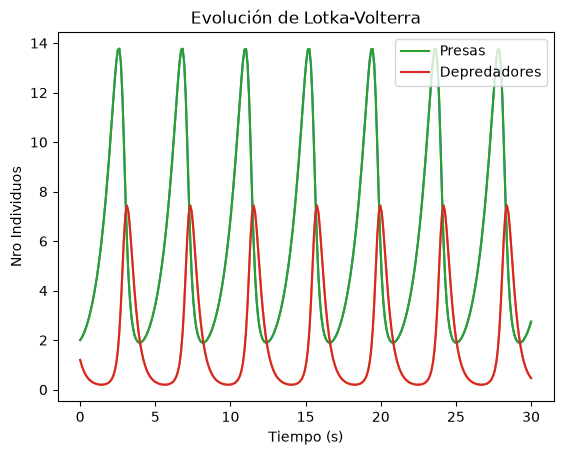

In [2]:
# SIMULACION DE LOTKA-VOLTERRA CON RK4
import numpy as np
import matplotlib.pyplot as plt

Nt = 300
T = 30.0
time = np.linspace(0, T, Nt)
dt = time[1] - time[0]

def F(x0, params):
    x = np.zeros((Nt, 2))
    x[0] = x0

    def f(x):
        alpha, beta, delta, gamma = params
        x1, x2 = x
        dx1dt = alpha * x1 - beta * x1 * x2
        dx2dt = delta * x1 * x2 - gamma * x2
        return np.array([dx1dt, dx2dt])
    
    for k in range(Nt-1):
        x1, x2 = x[k]
        k1 = f(x[k])
        k2 = f(x[k] + 0.5 * dt * k1)
        k3 = f(x[k] + 0.5 * dt * k2)
        k4 = f(x[k] + dt * k3)
        x[k+1] = x[k] + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return x

alpha = 1.0
beta = 0.5
delta = 0.5
gamma = 3.0
x0 = [2.0, 1.2]
params = [alpha, beta, delta, gamma]
x = F(x0, params)
plt.plot(time, x)

plt.plot(time, x[:,0], label="Presas")
plt.plot(time, x[:,1], label="Depredadores")
plt.xlabel("Tiempo (s)")
plt.ylabel("Nro Individuos")
plt.title("Evolución de Lotka-Volterra")
plt.legend(loc="upper right")
plt.show()

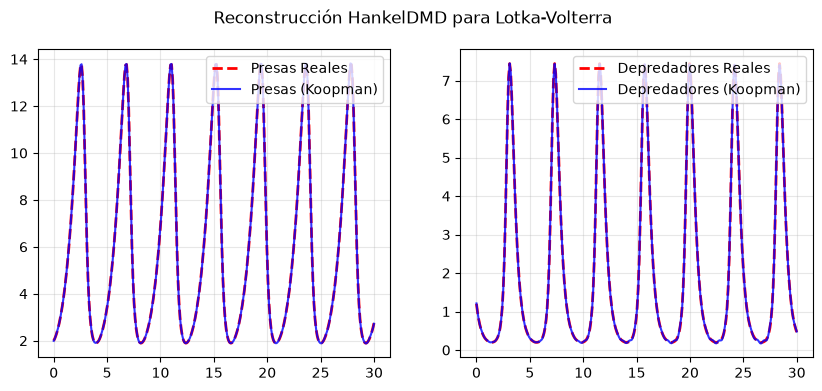

In [5]:
from pydmd import HankelDMD

dmd = HankelDMD(svd_rank=16, d=60)
dmd.fit(x.T)

rec = dmd.reconstructed_data.real

# 5. Visualización
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(time, x[:,0], 'r--', label='Presas Reales', linewidth=2)
plt.plot(time, rec[0], 'b-', label='Presas (Koopman)', alpha=0.8)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.subplot(1,2,2)
plt.plot(time, x[:,1], 'r--', label='Depredadores Reales', linewidth=2)
plt.plot(time, rec[1], 'b-', label='Depredadores (Koopman)', alpha=0.8)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.suptitle('Reconstrucción HankelDMD para Lotka-Volterra')
plt.show()

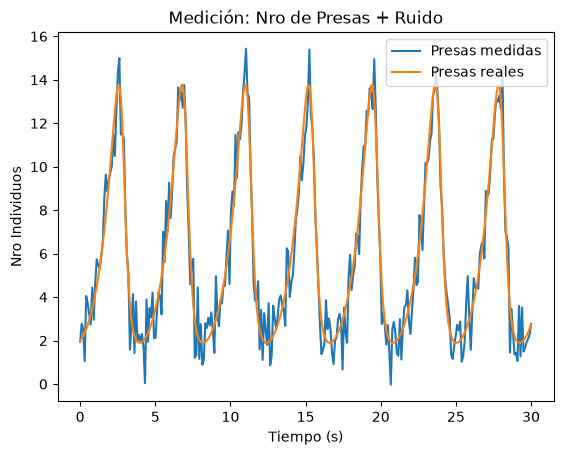

In [6]:
# MEDICION RUIDOSA
sigma_noise = 1.0
np.random.seed(37)
y = x[:,0] + np.random.normal(0, sigma_noise, size=Nt)

plt.plot(time, y, label='Presas medidas')
plt.plot(time, x[:,0], label='Presas reales')
plt.xlabel("Tiempo (s)")
plt.ylabel("Nro Individuos")
plt.title("Medición: Nro de Presas + Ruido")
plt.legend()
plt.show()

# EXTRAER INFORMACIÓN DE KOOPMAN
Lambda = np.diag(dmd.eigs)   # Matriz de transición diagonal (r x r)
Phi = dmd.modes              # Proyección a variables físicas (2 x r)
z0 = dmd.amplitudes           # Estado inicial modal (r,)

# Matrices de observación para Presas (A) y Depredadores (B)
C_A = Phi[0:1, :]  # Fila 0: Presas A
C_B = Phi[1:2, :]  # Fila 1: Depredadores B

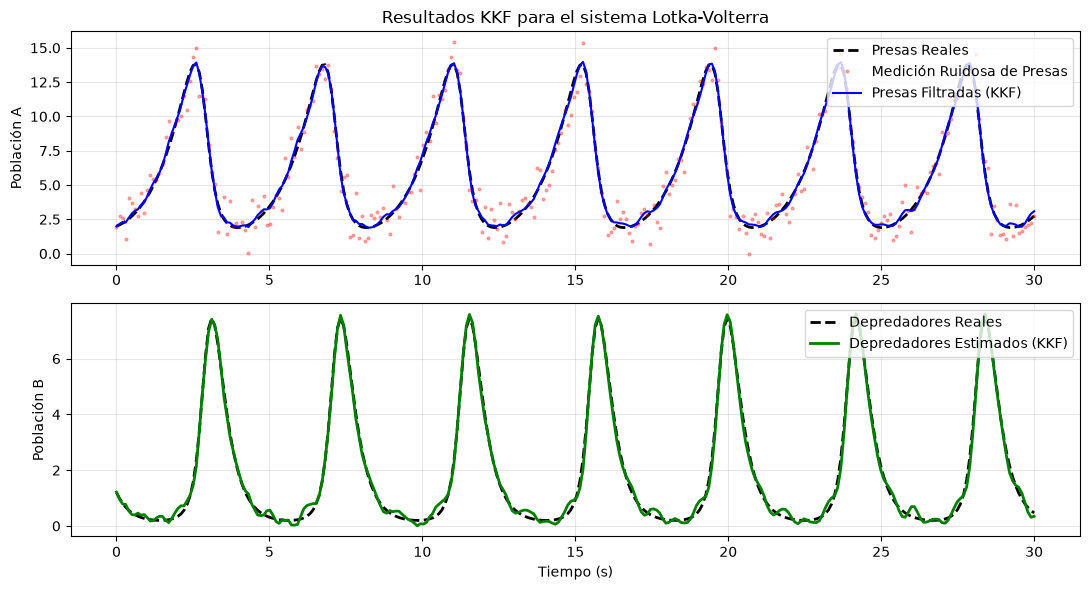

In [7]:
# Inicializar Filtro de Kalman en el espacio modal
r_rank = len(dmd.eigs)
z_hat = z0.astype(complex)

x1_est = np.zeros(Nt)
x2_est = np.zeros(Nt)

# Inicializar Matrices de Covarianzas
P = np.eye(r_rank, dtype=complex) * 1.0
Q = np.eye(r_rank, dtype=complex) * 1e-4
R = np.array([[sigma_noise**2]], dtype=complex)

# Filtro de Kalman Online
for k in range(Nt):
    # Paso 1: Predicción (Modos del sistema Koopman)
    if k > 0:
        z_pred = Lambda @ z_hat
        P_pred = Lambda @ P @ Lambda.conj().T + Q
    else:
        z_pred = z_hat
        P_pred = P

    # Paso 2: Lectura del sensor y cálculo de Innovación
    y_k = y[k]
    innovation = y_k - np.real((C_A @ z_pred)[0])

    # Paso 3: Ganancia de Kalman y Corrección de Estado
    S_k = C_A @ P_pred @ C_A.conj().T + R
    K = P_pred @ C_A.conj().T @ np.linalg.inv(S_k)

    z_hat = z_pred + K.flatten() * innovation # Corrección del estado modal
    P = (np.eye(r_rank) - K @ C_A) @ P_pred

    # Paso 4: Inferencia / Reconstrucción de variables usando los modos corregidos
    x1_est[k] = np.real((C_A @ z_hat)[0])
    x2_est[k] = np.real((C_B @ z_hat)[0])

# 5. Visualización de Resultados
plt.figure(figsize=(11, 6))

plt.subplot(2, 1, 1)
plt.plot(time, x[:, 0], 'k--', label='Presas Reales', linewidth=2)
plt.plot(time, y, 'r.', label='Medición Ruidosa de Presas', alpha=0.3, markersize=4)
plt.plot(time, x1_est, 'b-', label='Presas Filtradas (KKF)', linewidth=1.5)
plt.ylabel('Población A')
plt.legend(loc='upper right')
plt.title('Resultados KKF para el sistema Lotka-Volterra')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(time, x[:, 1], 'k--', label='Depredadores Reales', linewidth=2)
plt.plot(time, x2_est, 'g-', label='Depredadores Estimados (KKF)', linewidth=2)
plt.ylabel('Población B')
plt.xlabel('Tiempo (s)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()